# ReTReK route scoring

This tutorial scores finished synthesis routes with the ReTReK CD, AS, RD, and ST reaction heuristics. Scoring happens **after** planning and consumes detached `Route` objects: it does not walk the MCTS tree or change the search score.

## The post-processing boundary

The data flow is `tree.routes()` → `list[Route]` → `RetrekRouteScorer.rank(routes)`. Each `Route` carries ordered `Step` objects, the exact product disconnected by each step, its rule ID, and the availability verdict needed by ASScore.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, SVG, display

from synplan.chem.reaction.routes.io import read_routes_json
from synplan.chem.reaction.routes.quality.retrek import (
    ASRouteScorer,
    CDRouteScorer,
    RDRouteScorer,
    STRouteScorer,
    RetrekRouteScorer,
    RetrekRouteScoringConfig,
)
from synplan.chem.reaction.routes.route import Route
from synplan.utils.loading import download_preset, load_reaction_rules
from chython import depict_settings

depict_settings(aam=False)

## Load the reaction rules

The serialized steps carry integer policy-rule IDs. Load the same ordered reaction-rule collection used by the `synplanner-gps` preset so each ID indexes the applicable canonical retro reactor.

In [2]:
repo_checkout = Path("tutorials").is_dir()
data_root = Path("tutorials/synplan_data") if repo_checkout else Path("synplan_data")

paths = download_preset("synplanner-gps", save_to=data_root)
reaction_rules_path = paths["reaction_rules"]
reaction_rules = load_reaction_rules(reaction_rules_path)

print(f"Loaded {len(reaction_rules):,} reaction rules")


Loaded 11,235 reaction rules


## Restore two detached Route objects

The compact fixture contains two routes selected from `new_retrek_routes.json`:

- route **0** contains one ring disconnection;
- route **1** contains no ring disconnection.

`Route.from_json` restores the step graph, rule IDs, and stock verdict without needing the original MCTS tree.

In [3]:
fixture_path = Path("data/retrek_route_examples.json")

route_trees = read_routes_json(fixture_path)
routes_by_id = {
    int(route_id): Route.from_json(route_tree)
    for route_id, route_tree in route_trees.items()
}
assert set(routes_by_id) == {0, 1}

selected_route_ids = (0, 1)
routes = [routes_by_id[route_id] for route_id in selected_route_ids]
routes


[<Route -: 6 steps, solved, no score>, <Route -: 5 steps, solved, no score>]

## Configure all four scores

The aggregate enables CD, AS, RD, and ST with relative weights 5.0, 0.5, 2.0, and 2.0. Each step is the normalized weighted mean

`(5·CD + 0.5·AS + 2·RD + 2·ST) / 9.5`

when all four component scores are available. The route score is the arithmetic mean of its step scores.

In [4]:
config = RetrekRouteScoringConfig(
    enabled_scores=("cd", "as", "rd", "st"),
    weights={"cd": 5.0, "as": 0.5, "rd": 2.0, "st": 2.0},
)
scorer = RetrekRouteScorer(config, reaction_rules=reaction_rules)
component_scorers = {
    "CDScore": CDRouteScorer(),
    "ASScore": ASRouteScorer(),
    "RDScore": RDRouteScorer(),
    "STScore": STRouteScorer(reaction_rules=reaction_rules),
}


## Route-level aggregation

Let $K_j$ be the reaction-level aggregate for step $j$. For a route containing $M$ reaction steps, the route score is their arithmetic mean:

$$
K_{\mathrm{route}}
= \frac{1}{M}\sum_{j=1}^{M} K_j
= \frac{1}{M}\sum_{j=1}^{M}
\left(
\frac{\sum_{i \in A_j} w_i s_{ij}}
     {\sum_{i \in A_j} w_i}
\right).
$$

Here, $s_{ij}$ is component score $i$ for reaction $j$, $w_i$ is its weight, and $A_j$ contains the scores available for that reaction. Every reaction step contributes equally to the final route score.


In [5]:
def route_breakdown(route: Route) -> pd.DataFrame:
    component_scores = {
        name: component.step_scores(route)
        for name, component in component_scorers.items()
    }
    aggregate_scores = scorer.step_scores(route)
    return pd.DataFrame(
        [
            {
                "step": index + 1,
                "rule_id": step.origin.rule_id,
                "CDScore": component_scores["CDScore"][index],
                "ASScore": component_scores["ASScore"][index],
                "RDScore": component_scores["RDScore"][index],
                "STScore": component_scores["STScore"][index],
                "aggregate": aggregate_scores[index],
            }
            for index, step in enumerate(route.steps)
        ]
    ).round({"CDScore": 3, "aggregate": 3})


## ASScore for one or more precursors

ASScore is the fraction of reaction precursors that are available:

`ASScore = number of available precursors / number of precursors`.

Consequently, a one-precursor step scores `1.0` when that precursor is available and `0.0` when it is unavailable. In these examples, route 0 step 4 and route 1 step 3 each have one available precursor and therefore score `1.0`.

## Compare a ring-disconnection route with an all-zero route

The tables report the calculated component scores and the drawings use the detached `Route` objects directly.

### Route route 0  
ReTReK score: **0.4181**

,step,rule_id,CDScore,ASScore,RDScore,STScore,aggregate
0,1,310,0.400,1.0,0.0,1.0,0.474
1,2,345,0.333,0.5,1.0,1.0,0.623
2,3,465,0.091,0.5,0.0,1.0,0.285
3,4,3,0.000,1.0,0.0,1.0,0.263
4,5,7,0.667,0.5,0.0,1.0,0.588
5,6,856,0.125,0.0,0.0,1.0,0.276


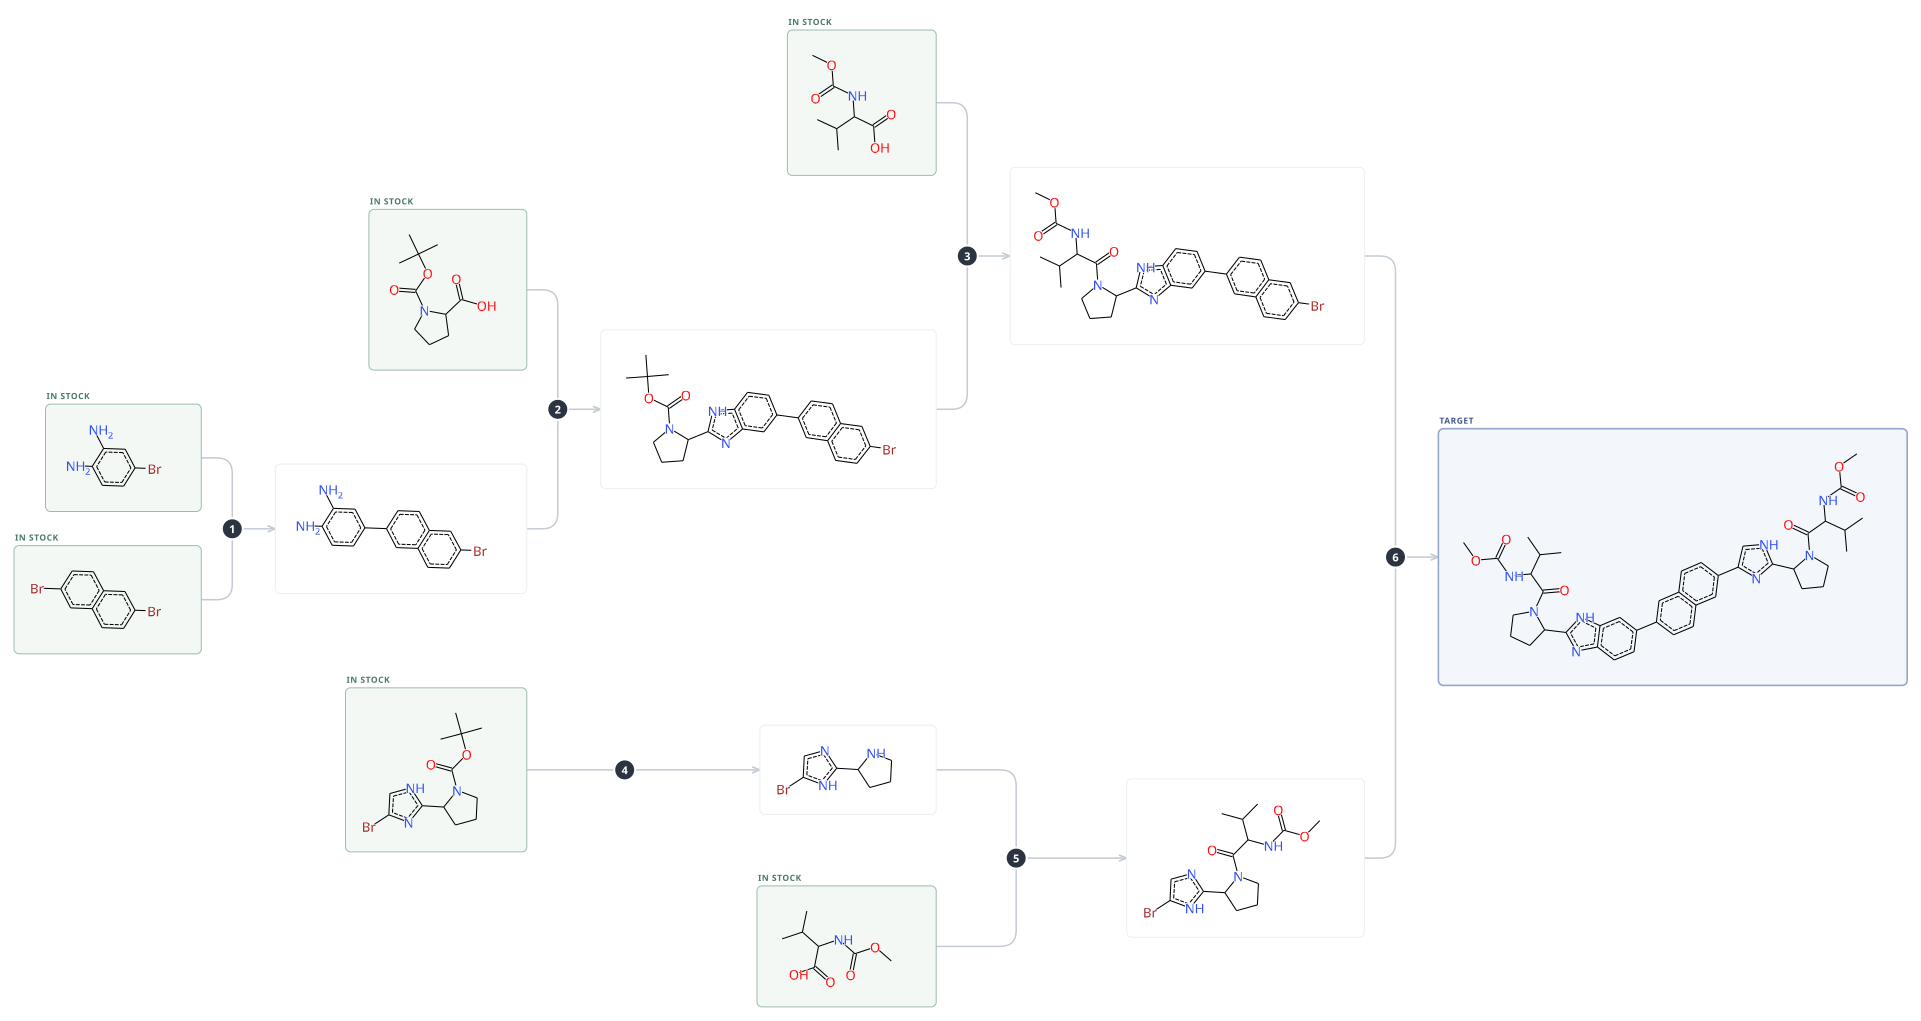

### Route route 1  
ReTReK score: **0.3526**

,step,rule_id,CDScore,ASScore,RDScore,STScore,aggregate
0,1,310,0.167,1.0,0.0,1.0,0.351
1,2,465,0.091,0.5,0.0,1.0,0.285
2,3,3,0.000,1.0,0.0,1.0,0.263
3,4,7,0.667,0.5,0.0,1.0,0.588
4,5,856,0.125,0.0,0.0,1.0,0.276


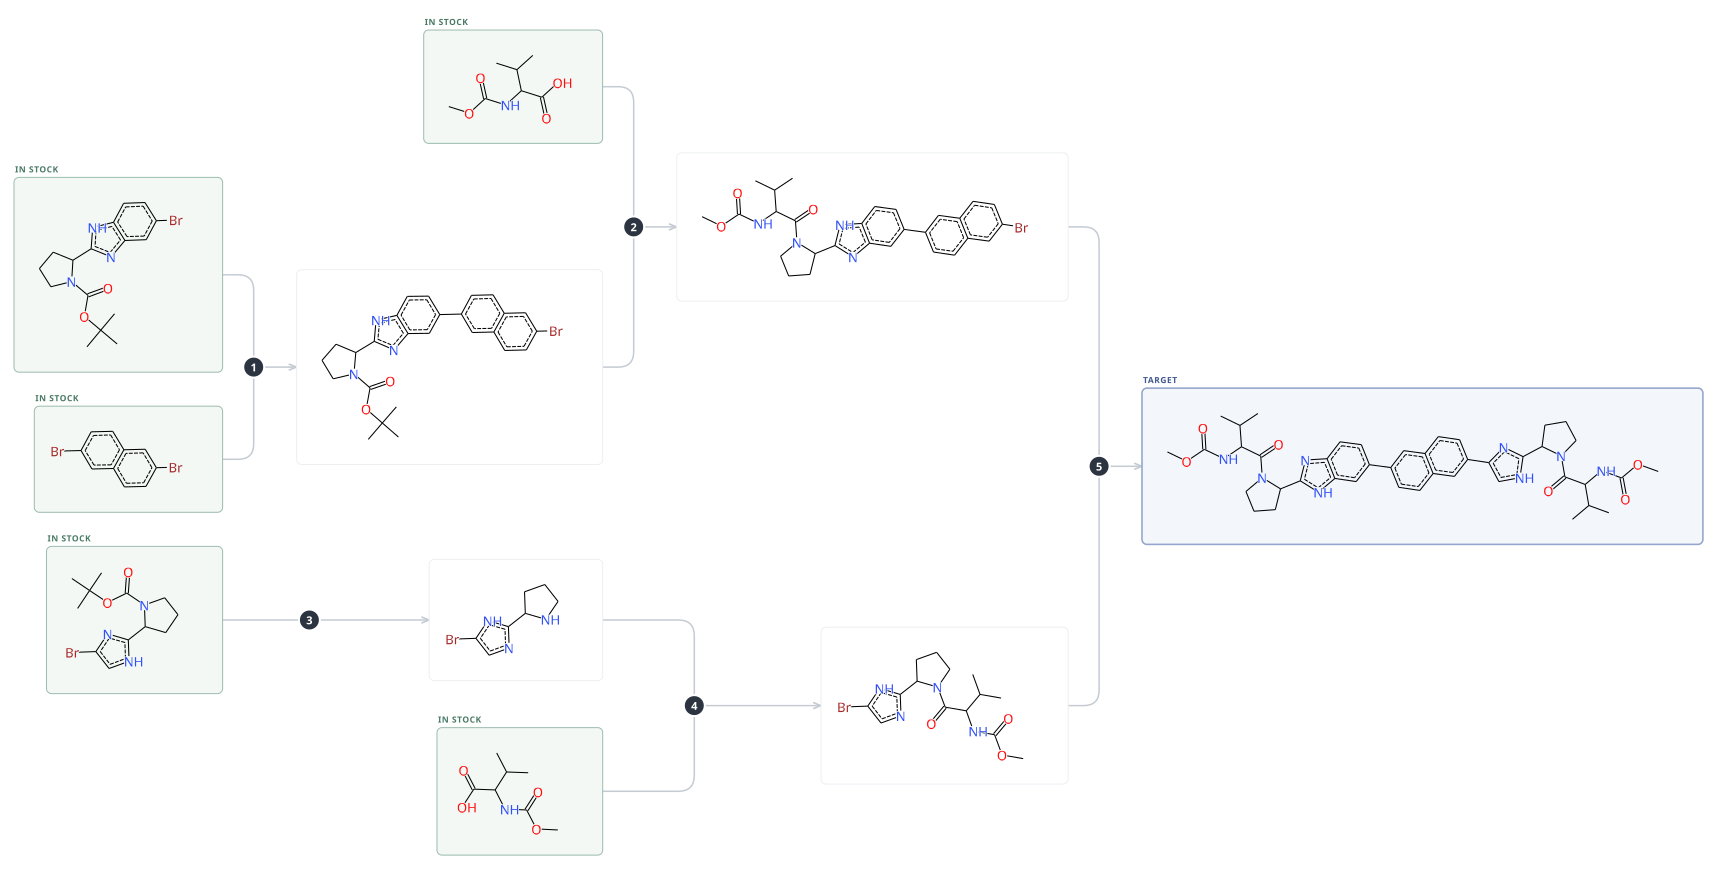

In [6]:
breakdowns = {}

for route_id in selected_route_ids:
    route = routes_by_id[route_id]
    breakdown = route_breakdown(route)
    breakdowns[route_id] = breakdown

    display(
        Markdown(
            f"### Route route {route_id}  \n"
            f"ReTReK score: **{scorer.score(route):.4f}**"
        )
    )
    display(breakdown)
    display(SVG(route.svg()))


In [7]:
summary = pd.DataFrame(
    [
        {
            "route_id": route_id,
            "steps": len(routes_by_id[route_id]),
            "RDScore pattern": tuple(breakdowns[route_id]["RDScore"]),
            "ReTReK score": scorer.score(routes_by_id[route_id]),
        }
        for route_id in selected_route_ids
    ]
)
summary


,route_id,steps,RDScore pattern,ReTReK score
0,0,6,"(0.0, 1.0, 0.0, 0.0, 0.0, 0.0)",0.418062
1,1,5,"(0.0, 0.0, 0.0, 0.0, 0.0)",0.352552


In [8]:
from synplan.chem.utils import mol_from_smiles

example_smiles = "O=C(O)C[C@H]1CCc2c1[nH]c1ccc(OCc3ccc(C4CCCC4)c(C(F)(F)F)c3)cc21"

target_molecule = mol_from_smiles(
    example_smiles,
    clean2d=True,
    standardize=True,
    clean_stereo=True
    )

/Users/almazgil/Developer/projects/SynPlannerReTReK/synplan/chem/utils.py:238: StereoDiscardedWarning: Input stereochemistry is being discarded: SynPlanner's rule application and its synthon/building-block stock are keyed on flat structures, so any route proposed for this molecule is racemic / relative configuration not determined.
  cleaned = clean_molecule(


In [9]:
target_molecule

In [10]:
from pathlib import Path

from synplan.utils.loading import download_preset

# Download preset data (or use already downloaded)
paths = download_preset("synplanner-gps", save_to="synplan_data")

# input data
ranking_policy_network = paths["ranking_policy"]
reaction_rules_path = paths["reaction_rules"]
building_blocks_path = paths["building_blocks"]


In [11]:
from synplan.mcts.tree import Tree
from synplan.utils.config import RolloutEvaluationConfig, TreeConfig
from synplan.utils.loading import (
    load_building_blocks,
    load_evaluation_function,
    load_policy_function,
    load_reaction_rules,
)

building_blocks = load_building_blocks(building_blocks_path, standardize=False)
reaction_rules = load_reaction_rules(reaction_rules_path)

policy_network = load_policy_function(weights_path=ranking_policy_network)

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=300,
    max_time=120,
    max_depth=9,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

eval_config = RolloutEvaluationConfig(
    policy_network=policy_network,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    min_mol_size=tree_config.min_mol_size,
    max_depth=tree_config.max_depth,
    normalize=True,
)
evaluation_function = load_evaluation_function(eval_config)

tree_1 = Tree(
    target=target_molecule,
    config=tree_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_network,
    evaluation_function=evaluation_function,
).run()

tree_1

  0%|          | 0/300 [00:00<?, ?it/s]

Tree for: FC(F)(F)c1c(ccc(c1)COc2ccc3c(c4c(C(CC(=O)O)CC4)[nH]3)c2)C5CCCC5
Time: 26.1 seconds
Number of nodes: 6756
Number of iterations: 300
Number of visited nodes: 299
Number of found routes: 213

In [12]:
routes = tree_1.routes()

## Compare the original and ReTReK rankings

The original ranking uses each route's MCTS search score. ReTReK then independently re-ranks the same finished `Route` objects. The table contains every route appearing in either top-10 set. A positive rank change means that ReTReK moved the route upward.

In [13]:
def original_search_score(route: Route) -> float:
    if route.provenance is None or route.provenance.search_score is None:
        raise ValueError("Every route must carry its original search score")
    return route.provenance.search_score


search_scores = {id(route): original_search_score(route) for route in routes}
retrek_scores = {id(route): scorer.score(route) for route in routes}

search_ranked_routes = sorted(
    routes, key=lambda route: search_scores[id(route)], reverse=True
)
retrek_ranked_routes = sorted(
    routes, key=lambda route: retrek_scores[id(route)], reverse=True
)
search_ranks = {id(route): rank for rank, route in enumerate(search_ranked_routes, 1)}
retrek_ranks = {id(route): rank for rank, route in enumerate(retrek_ranked_routes, 1)}

top_n = min(10, len(routes))
search_top = {id(route) for route in search_ranked_routes[:top_n]}
retrek_top = {id(route) for route in retrek_ranked_routes[:top_n]}
top_route_ids = search_top | retrek_top

ranking_changes = pd.DataFrame(
    [
        {
            "route_id": route.provenance.tree_node_id,
            "steps": len(route),
            "search_score": search_scores[id(route)],
            "search_rank": search_ranks[id(route)],
            "ReTReK_score": retrek_scores[id(route)],
            "ReTReK_rank": retrek_ranks[id(route)],
            "rank_change": search_ranks[id(route)] - retrek_ranks[id(route)],
            "top_set": (
                "both"
                if id(route) in search_top and id(route) in retrek_top
                else "search"
                if id(route) in search_top
                else "ReTReK"
            ),
        }
        for route in routes
        if id(route) in top_route_ids
    ]
).sort_values("ReTReK_rank")

display(Markdown(f"**Top-{top_n} overlap:** {len(search_top & retrek_top)}/{top_n}"))
ranking_changes.round({"search_score": 3, "ReTReK_score": 3})


**Top-10 overlap:** 0/10

,route_id,steps,search_score,search_rank,ReTReK_score,ReTReK_rank,rank_change,top_set
10,4539,6,0.121,11,0.395,1,10,ReTReK
12,4546,6,0.121,13,0.395,2,11,ReTReK
11,4540,6,0.121,12,0.393,3,9,ReTReK
14,4556,6,0.121,15,0.393,4,11,ReTReK
13,4549,6,0.121,14,0.392,5,9,ReTReK
17,4211,6,0.096,88,0.382,6,82,ReTReK
19,4218,6,0.096,90,0.382,7,83,ReTReK
15,3064,6,0.099,53,0.382,8,45,ReTReK
16,3071,6,0.099,55,0.382,9,46,ReTReK
18,4212,6,0.096,89,0.381,10,79,ReTReK


In [ ]:
display(route_breakdown(routes[0]))
routes[0]

,step,rule_id,CDScore,ASScore,RDScore,STScore,aggregate
0,1,431,0.500,1.0,1.0,0.5,0.632
1,2,12,0.000,0.0,0.0,1.0,0.211
2,3,5517,0.200,1.0,0.0,1.0,0.368
3,4,58,0.000,0.0,0.0,1.0,0.211
4,5,133,0.500,0.0,0.0,1.0,0.474
5,6,980,0.056,0.5,0.0,1.0,0.266


## Inspect the new top routes

The three highest ReTReK-ranked routes are shown with their original search ranks and reaction-level score breakdowns.

In [ ]:
for retrek_rank, route in enumerate(retrek_ranked_routes[:3], 1):
    route_id = route.provenance.tree_node_id
    display(
        Markdown(
            f"### ReTReK rank {retrek_rank}: route {route_id}  \n"
            f"Original search rank: **{search_ranks[id(route)]}** · "
            f"search score: **{search_scores[id(route)]:.3f}** · "
            f"ReTReK score: **{retrek_scores[id(route)]:.3f}**"
        )
    )
    display(route_breakdown(route))
    display(SVG(route.svg()))
